In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from scipy.stats import norm

In [53]:
@dataclass
class GammaScalpingSimulator:
    S0: float = 100.0
    E: float = 100.0
    r: float = 0.02
    sigma_imp: float = 0.20          # implied vol used for pricing/hedging
    T_years: float = 1.0             # maturity in years
    n_steps: int = 252
    n_paths: int = 2000
    seed: int = 2026

    def __post_init__(self):
        self.dt = self.T_years / self.n_steps
        self.time_grid = np.linspace(0.0, self.T_years, self.n_steps + 1)

  
    @staticmethod
    def _safe_tau(tau: np.ndarray, eps: float = 1e-10) -> np.ndarray:
        return np.maximum(tau, eps)

    def bs_d1(self, S: np.ndarray, tau: np.ndarray, sigma: float) -> np.ndarray:
        tau = self._safe_tau(tau)
        return (np.log(S / self.E) + (self.r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))

    def bs_d2(self, S: np.ndarray, tau: np.ndarray, sigma: float) -> np.ndarray:
        tau = self._safe_tau(tau)
        return self.bs_d1(S, tau, sigma) - sigma * np.sqrt(tau)

    def call_price(self, S: np.ndarray, tau: np.ndarray, sigma: float) -> np.ndarray:
        tau = self._safe_tau(tau)
        d1 = self.bs_d1(S, tau, sigma)
        d2 = d1 - sigma * np.sqrt(tau)
        return S * norm.cdf(d1) - self.E * np.exp(-self.r * tau) * norm.cdf(d2)

    def delta_call(self, S: np.ndarray, tau: np.ndarray, sigma: float) -> np.ndarray:
        tau = self._safe_tau(tau)
        d1 = self.bs_d1(S, tau, sigma)
        return norm.cdf(d1)

    def gamma_call(self, S: np.ndarray, tau: np.ndarray, sigma: float) -> np.ndarray:
        tau = self._safe_tau(tau)
        d1 = self.bs_d1(S, tau, sigma)
        return norm.pdf(d1) / (S * sigma * np.sqrt(tau))

    def plot_gamma_vs_ttm(self, spot_levels=(80, 90, 100, 110, 120), sigma=None):
            sigma = self.sigma_imp if sigma is None else sigma
            tau_grid = np.linspace(1/252, self.T_years, 300)
    
            plt.figure(figsize=(8, 5))
            for S in spot_levels:
                gamma_vals = self.gamma_call(np.full_like(tau_grid, S), tau_grid, sigma)
                moneyness = S / self.E
                plt.plot(tau_grid, gamma_vals, label=f"S/E={moneyness}")
            plt.gca().invert_xaxis()
            plt.xlabel("Time to maturity (years)")
            plt.ylabel("Gamma")
            plt.title("Gamma vs Time to Maturity")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()

    def plot_gamma_vs_moneyness(self, tau_levels=(5/252, 21/252, 63/252, 126/252), sigma=None):
        sigma = self.sigma_imp if sigma is None else sigma
        S_grid = np.linspace(0.6 * self.E, 1.4 * self.E, 400)
        moneyness = S_grid / self.E

        plt.figure(figsize=(8, 5))
        for tau in tau_levels:
            gamma_vals = self.gamma_call(S_grid, np.full_like(S_grid, tau), sigma)
            plt.plot(moneyness, gamma_vals, label=f"tau={tau:.3f}y")
        plt.xlabel("Moneyness S/E")
        plt.ylabel("Gamma")
        plt.title("Gamma vs Moneyness")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    def simulate_paths(self, sigma_path_type="constant", sigma_low=0.15, sigma_high=0.35,
                       switch_step=None):
        rng = np.random.default_rng(self.seed)
        Z = rng.standard_normal((self.n_steps, self.n_paths))

        S = np.zeros((self.n_steps + 1, self.n_paths))
        S[0, :] = self.S0

        sigma_realized = np.zeros((self.n_steps, self.n_paths))

        if sigma_path_type == "constant":
            sigma_realized[:, :] = sigma_high

        elif sigma_path_type == "regime_switch":
            if switch_step is None:
                switch_step = self.n_steps // 2
            sigma_realized[:switch_step, :] = sigma_low
            sigma_realized[switch_step:, :] = sigma_high

        

        #elif sigma_path_type == "random_vol":
           
        else:
            raise ValueError("Unknown sigma_path_type")

        for t in range(self.n_steps):
            sig_t = sigma_realized[t, :]
            S[t + 1, :] = S[t, :] * np.exp(
                (self.r - 0.5 * sig_t**2) * self.dt + sig_t * np.sqrt(self.dt) * Z[t, :]
            )

        return S, sigma_realized

    def run_gamma_scalping(self, sigma_path_type="constant", sigma_low=0.15, sigma_high=0.35, switch_step=None):
            
        S, sigma_realized = self.simulate_paths(
            sigma_path_type=sigma_path_type,
            sigma_low=sigma_low,
            sigma_high=sigma_high,
            switch_step=switch_step,
           
            )

        tau = self.T_years - self.time_grid[:-1]  # tau at step start, shape (n_steps,)
        tau_2d = np.repeat(tau[:, None], self.n_paths, axis=1)

        S_t = S[:-1, :]
        S_tp1 = S[1:, :]
        dS = S_tp1 - S_t

        gamma_imp = self.gamma_call(S_t, tau_2d, self.sigma_imp)
        theta_carry = 0.5 * gamma_imp * (S_t**2) * (self.sigma_imp**2) * self.dt
        realized_term = 0.5 * gamma_imp * (dS**2)

        # use the discrete gamma-scalping P&L formula
        pnl_step = realized_term - theta_carry
        pnl_cum = np.vstack([np.zeros((1, self.n_paths)), np.cumsum(pnl_step, axis=0)])

        
        delta_imp = self.delta_call(S_t, tau_2d, self.sigma_imp)

        return {
            "S": S,
            "sigma_realized": sigma_realized,
            "gamma_imp": gamma_imp,
            "delta_imp": delta_imp,
            "pnl_step": pnl_step,
            "pnl_cum": pnl_cum,
            "time_grid": self.time_grid
        }

    
    def plot_single_path_diagnostics(self, result, path_id=0):
        t = result["time_grid"][:-1]
        S = result["S"][:, path_id]
        gamma = result["gamma_imp"][:, path_id]
        pnl_step = result["pnl_step"][:, path_id]
        pnl_cum = result["pnl_cum"][:, path_id]

        fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

        axes[0].plot(result["time_grid"], S)
        axes[0].axhline(self.E, linestyle="--", alpha=0.6)
        axes[0].set_ylabel("Spot")
        axes[0].set_title(f"Single Path Diagnostics (path {path_id})")
        # spot price: based on time point
        
        axes[1].plot(t, S[:-1] / self.E)
        axes[1].axhline(1.0, linestyle="--", alpha=0.6)
        axes[1].set_ylabel("Moneyness S/E")

        axes[2].plot(t, gamma)
        axes[2].set_ylabel("Gamma")
        #axes[2].set_xlabel("Time elapsed")
        axes[2].set_title('Time-dependent Gamma', fontsize=12)
        # gamma: based on time inveral

        ax_left = axes[3]
        ax_right = ax_left.twinx()

        line1 = ax_left.plot(t, pnl_step, label="Step P&L", color='tab:red', alpha=0.8)
        ax_left.set_ylabel("Step P&L", color='tab:red')

        line2 = ax_right.plot(result["time_grid"], pnl_cum, label="Cumulative P&L", color='tab:blue', linewidth=2)
        ax_right.set_ylabel("Cumulative P&L", color='tab:blue')
        
        #axes[3].plot(t, pnl_step, label="step P&L")
        #axes[3].plot(result["time_grid"], pnl_cum, label="cum P&L")
        
        mid = self.T_years / 2
        ax_left.axvspan(0, mid, color='red', alpha=0.1, label='Regime 1: Act Vol (10%) < Imp Vol (20%)')
        ax_left.axvspan(mid, self.T_years, color='green', alpha=0.1, label='Regime 2: Act Vol (40%) > Imp Vol (20%)')
        
        #ax_left.legend(loc='upper left')
        ax_left.set_title('P&L by Regime Shift (Time-Varying Actual Vol)', fontsize=12)
   
        ax_left.set_xlabel("Time elapsed")

        handles_left, labels_left = ax_left.get_legend_handles_labels()
        handles_right, labels_right = ax_right.get_legend_handles_labels()
        ax_left.legend(handles_left + handles_right, labels_left + labels_right , loc='upper left')

 
        # P&L for time step: based on time interval
        # accumulated P&L: based on time point

        for ax in axes:
            ax.grid(True, alpha=0.3)
            
        plt.tight_layout()    
        plt.show()

    def plot_distribution_of_terminal_pnl(self, result):
        terminal = result["pnl_cum"][-1, :]
        plt.figure(figsize=(8, 5))
        plt.hist(terminal, bins=50, alpha=0.8)
        plt.xlabel("Terminal cumulative P&L")
        plt.ylabel("Frequency")
        plt.title("Distribution of Terminal Long-Gamma P&L")
        plt.grid(True, alpha=0.3)
        plt.show()

    def compare_vol_scenarios(self):
        scenarios = {
            "low realized vol": {"sigma_path_type": "constant", "sigma_high": 0.12},
            "equal to implied": {"sigma_path_type": "constant", "sigma_high": self.sigma_imp},
            "high realized vol": {"sigma_path_type": "constant", "sigma_high": 0.35},
            "regime switch": {"sigma_path_type": "regime_switch", "sigma_low": 0.10, "sigma_high": 0.40},
            
        }

        rows = []
        for name, kwargs in scenarios.items():
            res = self.run_gamma_scalping(**kwargs)
            terminal = res["pnl_cum"][-1, :]
            rows.append({
                "scenario": name,
                "mean_terminal_pnl": terminal.mean(),
                "std_terminal_pnl": terminal.std(),
                "p05": np.percentile(terminal, 5),
                "p50": np.percentile(terminal, 50),
                "p95": np.percentile(terminal, 95)
            })

        return pd.DataFrame(rows)




In [55]:
sim = GammaScalpingSimulator(
    S0=100,
    E=100,
    r=0.02,
    sigma_imp=0.20,
    T_years=1.0,
    n_steps=252,
    n_paths=3000,
    seed=2026
)

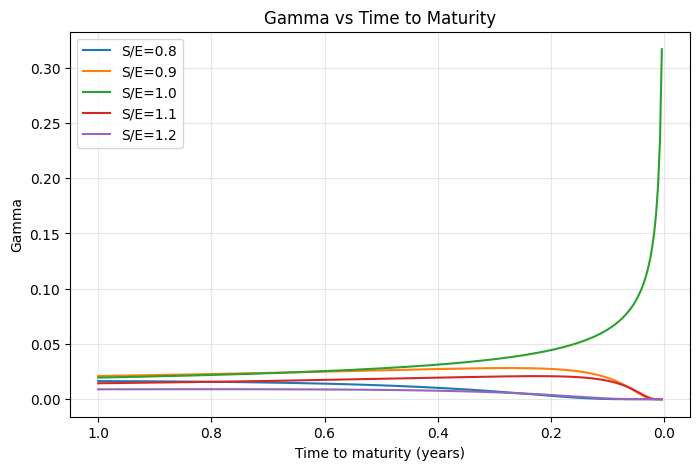

In [63]:
sim.plot_gamma_vs_ttm()

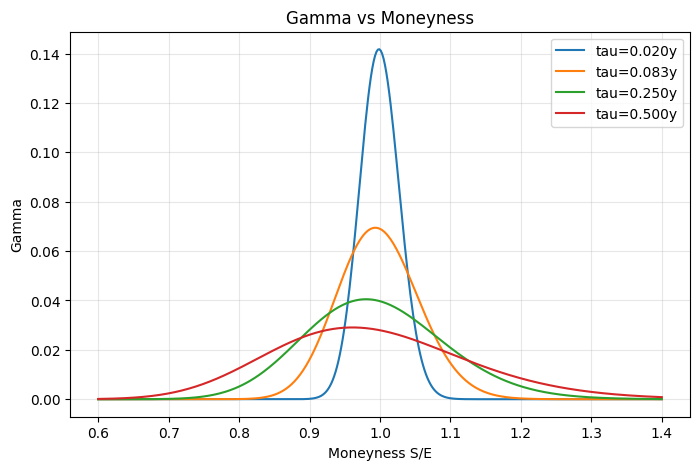

In [114]:
sim.plot_gamma_vs_moneyness()


In [57]:
res = sim.run_gamma_scalping(
    sigma_path_type="regime_switch",
    sigma_low=0.10,
    sigma_high=0.40
)

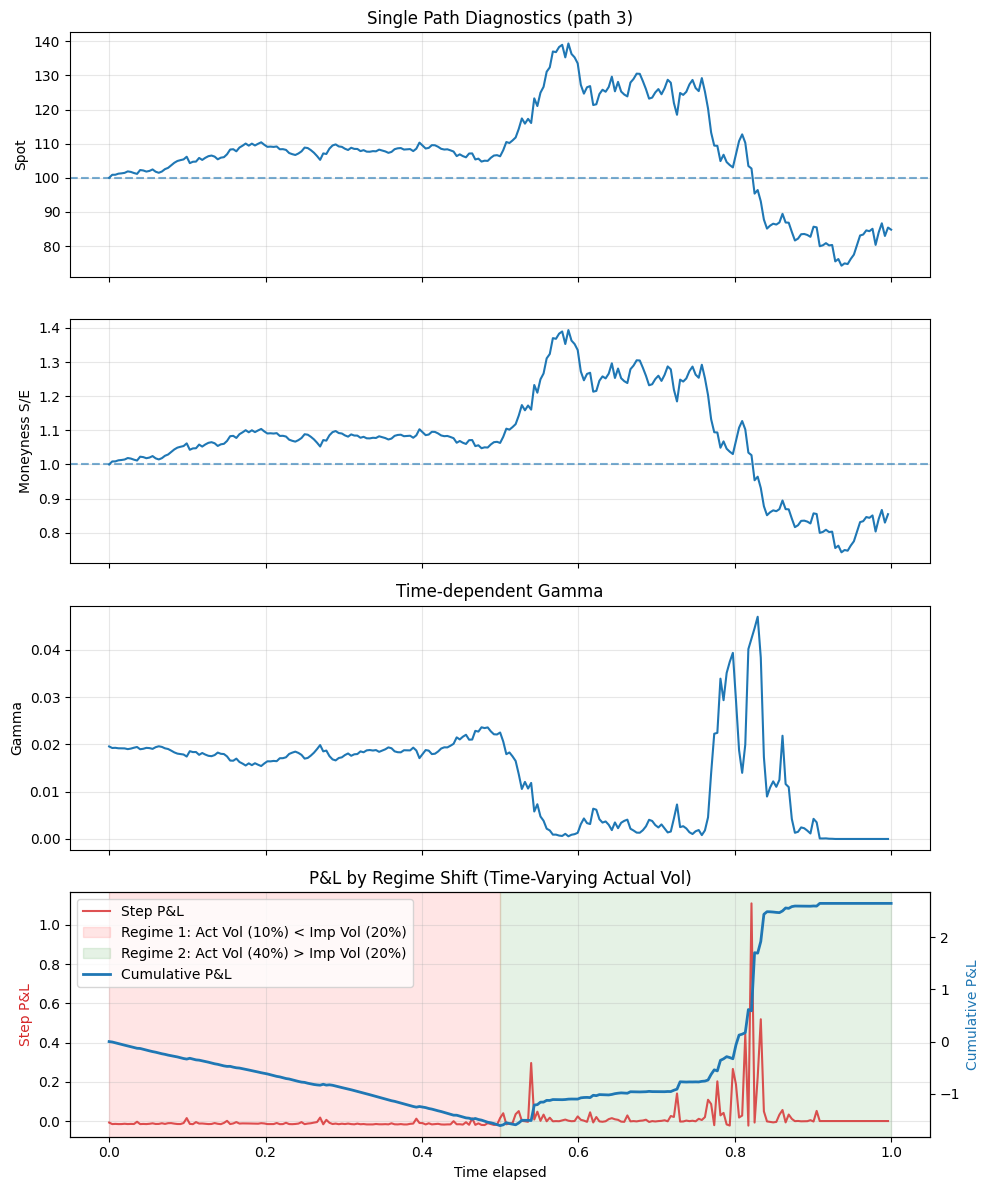

In [59]:
sim.plot_single_path_diagnostics(res, path_id=3)

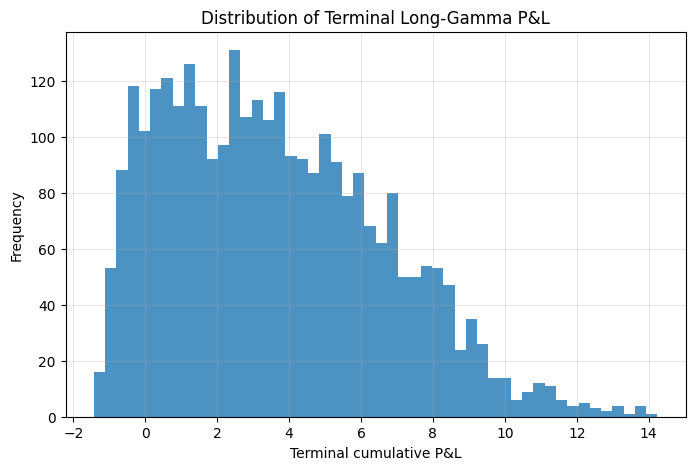

In [40]:
sim.plot_distribution_of_terminal_pnl(res)

In [42]:
summary = sim.compare_vol_scenarios()
print(summary)

            scenario  mean_terminal_pnl  std_terminal_pnl       p05       p50  \
0   low realized vol          -3.139544          0.901113 -4.561946 -3.162891   
1   equal to implied          -0.002314          0.422531 -0.670208 -0.010739   
2  high realized vol           5.882512          2.955342  1.754963  5.507238   
3      regime switch           3.619803          3.013144 -0.506898  3.253073   

         p95  
0  -1.653332  
1   0.683212  
2  11.098682  
3   8.954202  
